# Data Understanding Section

This notebook includes exploration of the collected in `01_data_collection.ipynb` data, prior to Data Preparation step.

In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ai_code_reviewer.dataset import (
    config,
)


In [3]:
df = pd.read_parquet(config.DATASET_PATH, engine="pyarrow")

## 1. Length Analysis

During the Data Preparation step most of our features will be text based. So, as LLMs (that we plan to use for modeling) have a limited content (amount of data that it could process at a single run) our main concern is connected with the length of data. 

Hence, as the first step of data understanding we will check distributions of various parts of our data. As we haven't chosen a specific family of models that we'll use we will use a common heuristic that 1 token ≈ 4 words.

Our planned building blocks that we want to feed into a model are:
1) Pull Request metadata (PR title + PR body)
2) Repository metadata:
    1) README.md files
    2) Various configuration files (setup.py, pyproject.toml, requirements.txt, e.t.c)
    3) File-tree structure
2) Main changed file (`patched_content`)
3) Incoming dependencies - files that uses identifiers (e.g function or class) that were changed in the main file
4) Outgoing dependencies - files that the main file uses (via imports)

Below we will check a distribution of each to understand wether we need to anyhow summarize or cut content to fit into a model. 

In [ ]:
def plot_token_length_distribution(strings: list[str], title: str, token_per_word: int = 4):
    """
    Plots a distribution of the estimated token lengths from a list of strings.
    Shows median, 75th, and 95th percentiles on the histogram legend.

    Args:
        strings (list[str]): List of input text snippets.
        title (str): Title for the plot.
        token_per_word (int, optional): Number of symbols per token. Defaults to 4.
    """
    # Calculate lengths in tokens
    lens = np.array([len(s) / token_per_word for s in strings])
    # Compute percentiles
    median = np.percentile(lens, 50)
    pct75 = np.percentile(lens, 75)
    pct95 = np.percentile(lens, 95)

    plt.figure(figsize=(8, 4))
    plt.hist(lens, bins=50, color="skyblue", edgecolor="black", alpha=0.7)
    plt.axvline(median, color="orange", linestyle="--", label=f"Median: {median:.1f}")
    plt.axvline(pct75, color="green", linestyle="--", label=f"75th: {pct75:.1f}")
    plt.axvline(pct95, color="red", linestyle="--", label=f"95th: {pct95:.1f}")
    plt.xlabel(f"Length (estimated tokens, 1 token ≈ {token_per_word} words)")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

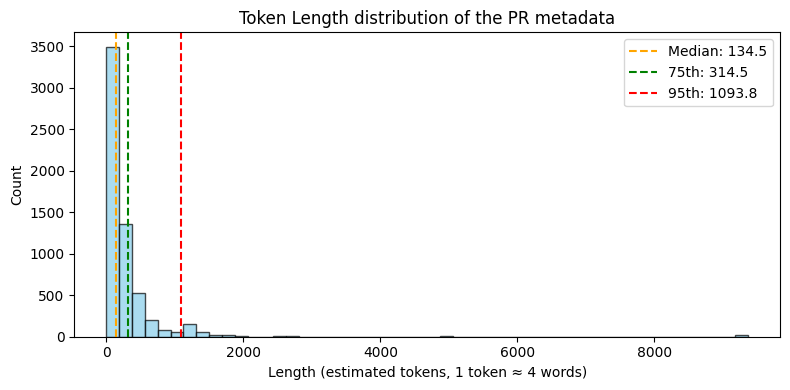

In [19]:
plot_token_length_distribution(
    df["pr_title"].astype("str") + "\n" + df["pr_body"].astype("str"),
    "Token Length distribution of the PR metadata",
)

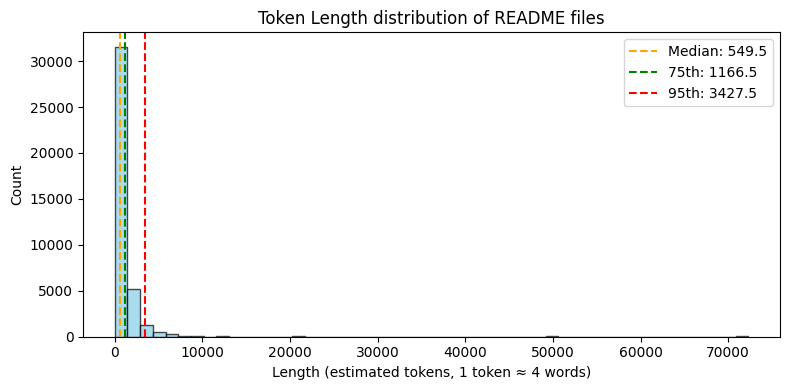

In [33]:
plot_token_length_distribution(
    [d["content"] for sublist in df["metadata_files"] for d in sublist if "README.md" in d.get("path", "")],
    "Token Length distribution of README files",
)

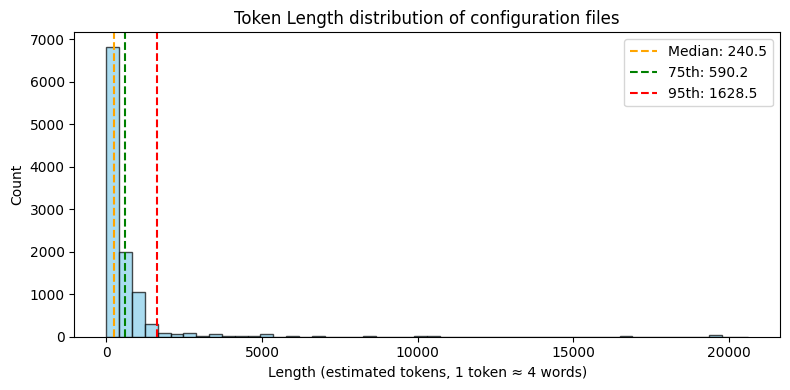

In [35]:
plot_token_length_distribution(
    [
        d["content"]
        for sublist in df["metadata_files"]
        for d in sublist
        if d.get("path", "")
        in [
            "requirements.txt",
            "setup.py",
            "setup.cfg",
            "pyproject.toml",
        ]
    ],
    "Token Length distribution of configuration files",
)

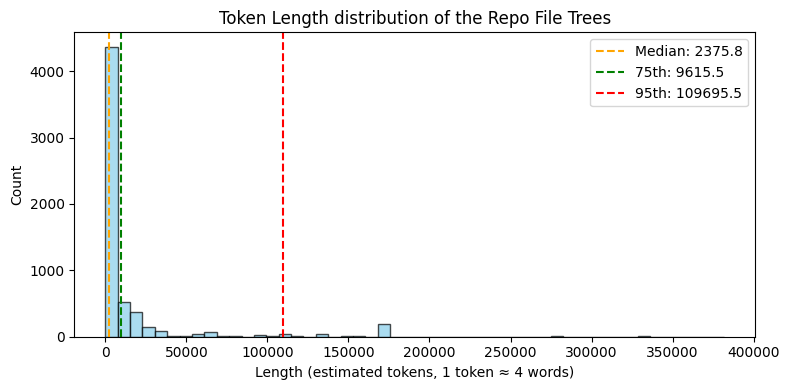

In [38]:
plot_token_length_distribution(df["file_tree"], "Token Length distribution of the Repo File Trees")

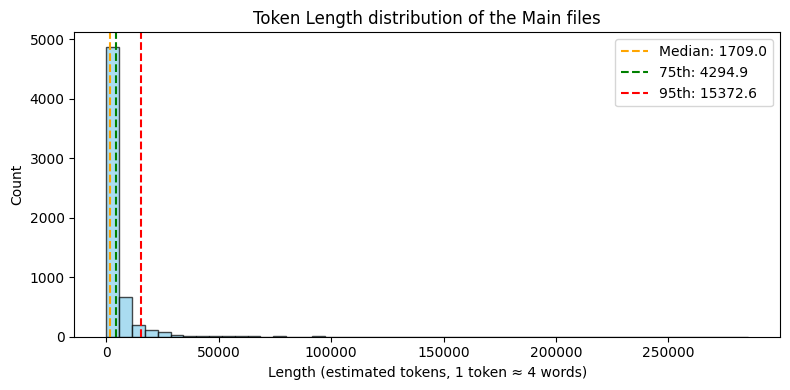

In [20]:
plot_token_length_distribution(df["patched_content"], "Token Length distribution of the Main files")

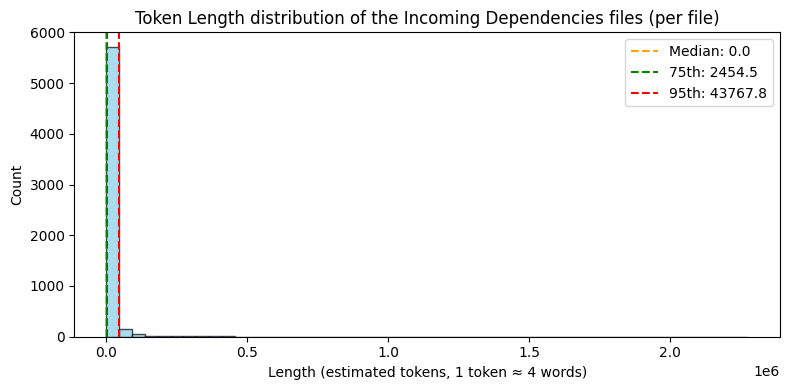

In [ ]:
# Main file could have multiple incoming dependencies
# Ideally, we want to include them all.
plot_token_length_distribution(
    ["/n".join(d["content"] for d in sublist) for sublist in df["incoming_dependencies"]],
    "Token Length distribution of the Incoming Dependency files (per main file)",
)

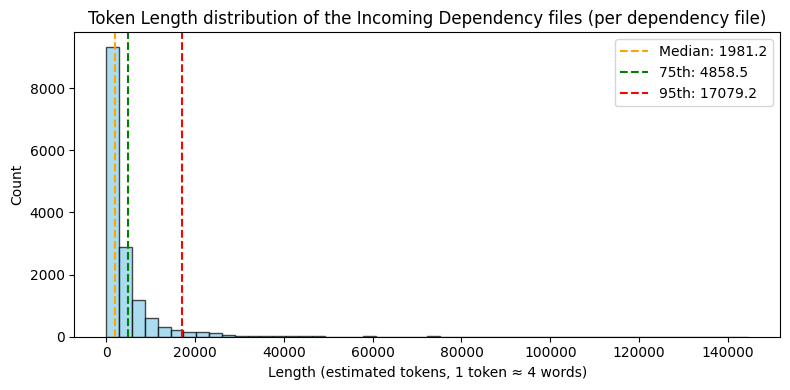

In [45]:
# Right tail of incoming dependencies length per main files looks infeasible for our models
# So, we probably will take only top N files. Thus, let's check distribution per file
plot_token_length_distribution(
    [d["content"] for sublist in df["incoming_dependencies"] for d in sublist],
    "Token Length distribution of the Incoming Dependency files (per dependency file)",
)

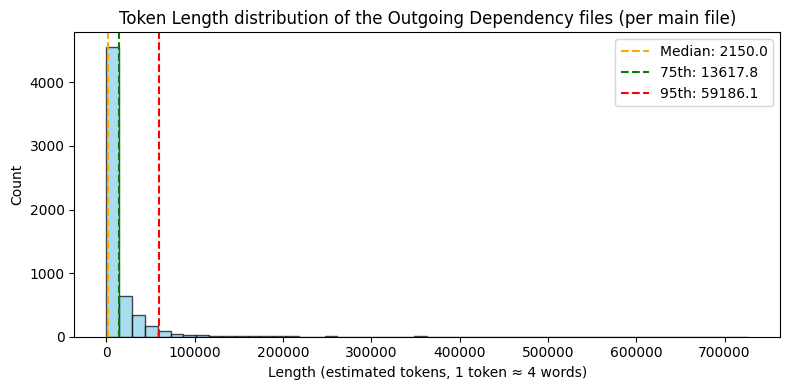

In [46]:
# Main file could have multiple outgoing dependencies
# Ideally, we want to include them all.
plot_token_length_distribution(
    ["/n".join(d["content"] for d in sublist) for sublist in df["outgoing_dependencies"]],
    "Token Length distribution of the Outgoing Dependency files (per main file)",
)

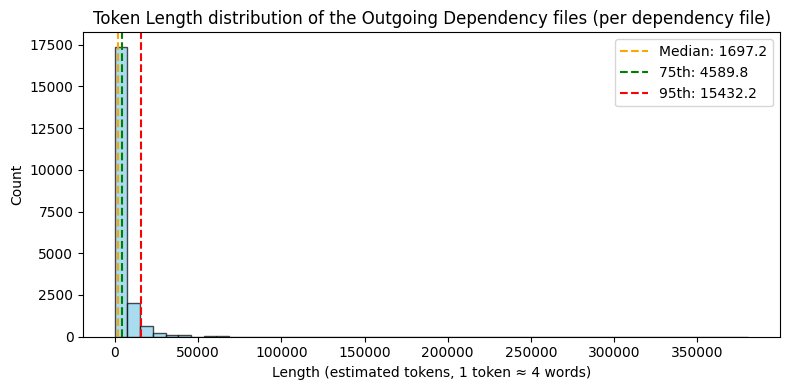

In [47]:
# Right tail of outgoing dependencies length per main files looks infeasible for our models
# So, we probably will take only top N files. Thus, let's check distribution per file
plot_token_length_distribution(
    [d["content"] for sublist in df["outgoing_dependencies"] for d in sublist],
    "Token Length distribution of the Outgoing Dependency files (per dependency file)",
)

## Example analysis

We've already checked distribution of each text block that we are going to feed into a model. Now we want to understand how could we minimize the content (for latency minimization and ability to include mode examples below hard model content length cap).

To accomplish this we need to manually analyze some examples of each content to check if some redundant structural parts could be excluded without loosing main context.

As we neither could manually analyze all of the example, nor use LLMs (due to context length limit, which we try to solve here), we will subsample 5 examples per content type and report observations based on the finding from these examples.
We understand that analysis of broader range of examples could give us more insights, but given the time and resource constraints of this project, we believe that the current approach is sufficient.

In [62]:
N_RANDOM_SAMPLES = 3

In [130]:
for i, pr in enumerate(df["pr_body"].sample(N_RANDOM_SAMPLES), 1):
    print(f"-------------------- EXAMPLE {i} --------------------")
    print(pr)

-------------------- EXAMPLE 1 --------------------
- fix #83
- use mrcfile https://github.com/ccpem/mrcfile (light-weight dependency) for file parsing
- new mrc module; functionality replaces CCP4 module
- keep CCP4 module for one release cycle
- add tests
-------------------- EXAMPLE 2 --------------------
Branch `main` refactored by [Sourcery](https://sourcery.ai/github/).

If you're happy with these changes, merge this Pull Request using the *Squash and merge* strategy.

See our documentation [here](https://docs.sourcery.ai/GitHub/Using-Sourcery-for-GitHub/).

<details>
<summary>Run Sourcery locally</summary>
<p>
Reduce the feedback loop during development by using the Sourcery editor plugin:
</p>
<ul>
<li><a href="https://sourcery.ai/download/?editor=vscode">VS Code</a></li>
<li><a href="https://sourcery.ai/download/?editor=pycharm">PyCharm</a></li>
</ul>
</details>

<details>
<summary>Review changes via command line</summary>
<p>To manually merge these changes, make sure you're o

In [ ]:
readme_contents = [
    d["content"] for sublist in df["metadata_files"] for d in sublist if "README.md" in d.get("path", "")
]
for i, readme in enumerate(random.sample(readme_contents, min(N_RANDOM_SAMPLES, len(readme_contents))), 1):
    print(f"-------------------- EXAMPLE {i} --------------------")
    print(readme)

-------------------- EXAMPLE 1 --------------------
# C++ Frontend Tests

In this folder live the tests for PyTorch's C++ Frontend. They use the
[GoogleTest](https://github.com/google/googletest) test framework.

## CUDA Tests

To make a test runnable only on platforms with CUDA, you should suffix your
test with `_CUDA`, e.g.

```cpp
TEST(MyTestSuite, MyTestCase_CUDA) { }
```

To make it runnable only on platforms with at least two CUDA machines, suffix
it with `_MultiCUDA` instead of `_CUDA`, e.g.

```cpp
TEST(MyTestSuite, MyTestCase_MultiCUDA) { }
```

There is logic in `main.cpp` that detects the availability and number of CUDA
devices and supplies the appropriate negative filters to GoogleTest.

## Integration Tests

Integration tests use the MNIST dataset. You must download it by running the
following command from the PyTorch root folder:

```sh
$ python tools/download_mnist.py -d test/cpp/api/mnist
```

The required paths will be referenced as `test/cpp/api/mnist/...` in the test

In [141]:
config_contents = [
    d["content"]
    for sublist in df["metadata_files"]
    for d in sublist
    if d.get("path", "")
    in [
        "requirements.txt",
        "setup.py",
        "setup.cfg",
        "pyproject.toml",
    ]
]
for i, config in enumerate(random.sample(config_contents, min(N_RANDOM_SAMPLES, len(config_contents))), 1):
    print(f"-------------------- EXAMPLE {i} --------------------")
    print(config)

-------------------- EXAMPLE 1 --------------------
[flake8]
max-line-length = 99
ignore = E731, E402, W504, N818

[isort]
line_length=99
known_future_library=future
multi_line_output=3
known_first_party=rotkehlchen
include_trailing_comma=1
default_section=THIRDPARTY
combine_as_imports=1

[mypy]
# Docs: https://mypy.readthedocs.io/en/latest/config_file.html
ignore_missing_imports = True
check_untyped_defs = True
disallow_untyped_defs = True
warn_unused_configs = True
warn_unused_ignores = True
warn_unreachable = True
warn_redundant_casts = True
disallow_untyped_decorators = True
disallow_untyped_calls = True
mypy_path=./stubs/

# -- These modules still need to have proper type definitions given --
[mypy-rotkehlchen.tests.*]
check_untyped_defs = False
disallow_untyped_defs = False
# Pytest's fixture decorators are not typed
disallow_untyped_decorators = False

# Data faker is a WIP so skip strict type checks
[mypy-data_faker.*]
check_untyped_defs = False
disallow_untyped_defs = False

#

In [142]:
for i, tree in enumerate(df["file_tree"].sample(N_RANDOM_SAMPLES)):
    print(f"-------------------- EXAMPLE {i} --------------------")
    print(tree)

-------------------- EXAMPLE 0 --------------------
pydocstringformatter/
├── .github/
│   ├── workflows/
│   │   ├── publish.yaml
│   │   └── tests.yaml
│   └── CONTRIBUTING.md
├── pydocstringformatter/
│   ├── formatting/
│   │   ├── __init__.py
│   │   ├── base.py
│   │   └── formatter.py
│   ├── utils/
│   │   ├── __init__.py
│   │   ├── argument_parsing.py
│   │   ├── exceptions.py
│   │   ├── find_docstrings.py
│   │   └── find_python_file.py
│   ├── __init__.py
│   ├── __main__.py
│   └── run.py
├── tests/
│   ├── data/
│   │   ├── config/
│   │   │   ├── invalid_toml/
│   │   │   │   ├── test_package/
│   │   │   │   │   └── correct_docstring.py
│   │   │   │   └── pyproject.toml
│   │   │   ├── no_toml/
│   │   │   │   └── test_package/
│   │   │   │       └── incorrect_docstring.py
│   │   │   ├── non_existing_options/
│   │   │   │   ├── test_package/
│   │   │   │   │   └── correct_docstring.py
│   │   │   │   └── pyproject.toml
│   │   │   ├── valid_toml/
│   │   │   │   ├

In [143]:
for i, content in enumerate(df["patched_content"].sample(N_RANDOM_SAMPLES)):
    print(f"-------------------- EXAMPLE {i} --------------------")
    print(content)

-------------------- EXAMPLE 0 --------------------
import logging as log
from pathlib import Path
import shutil

from fud.stages import Source, SourceType, Stage
from fud.stages.remote_context import RemoteExecution
from fud.stages.futil import FutilStage
-from fud.utils import TmpDir, shell
+from fud.utils import TmpDir, FreshDir, shell


class XilinxStage(Stage):
    name = "xclbin"

    def __init__(self, config):
        super().__init__(
            src_state="futil",
            target_state="xclbin",
            input_type=SourceType.Path,
            output_type=SourceType.Stream,
            config=config,
            description="compiles Calyx programs to Xilinx bitstreams",
        )

        # tcl files
        self.gen_xo_tcl = (
            Path(self.config["global", "futil_directory"])
            / "fud"
            / "bitstream"
            / "gen_xo.tcl"
        )

        # sub stages to use futil to compile
        self.xilinx_futil = FutilStage(config, "xilinx-ve

## Dependency Analysis

Aside for the main file content, PR and repo metadata, we also want to include information about dependencies.
We differentiate two types of dependencies:
- Incoming dependencies - files that uses identifiers (e.g function or class) that were changed in the main file. These files could potentially show if any part of the codebase uses old functionality, which was changed in the PR.
- Outgoing dependencies - files that the main file uses (via imports). These files could potentially show if the current code uses outdated functionality from other parts of the codebase.

Though, ideally we want to include all the dependencies, as 'Length Analysis' section shows, it's not feasible for some of the files (due to length of the content). Hence, we need to identify a reasonable threshold of the number of dependencies that we should include.

In [146]:
pd.Series([len(sublist) for sublist in df["incoming_dependencies"]]).describe()

count    6011.000000
mean        2.543504
std        13.777259
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       460.000000
dtype: float64

In [147]:
pd.Series([len(sublist) for sublist in df["outgoing_dependencies"]]).describe()

count    6011.000000
mean        3.408418
std         5.869977
min         0.000000
25%         0.000000
50%         2.000000
75%         4.000000
max       116.000000
dtype: float64

## Results

Based on the analysis above, here is the list of the files that we will use for the modeling and how we will transform (truncate) them:
- PR title + PR body:
    - We will use first 500 characters (about 125 tokens). From the example analysis it seems that this is enough to keep intuition of what changes were made in the PR, while removing redundant parts (e.g some PR list exact files that were changed).
    - We will strip HTML tags from the PR body. Though, most of PR body content is in markdown, GitHub supports HTML tags, which for our use case are too verbose. Thus, we will remove tags themselves, while keeping the text content. In such a way we will lower verbosity, while keeping the most of the information.
- Repository metadata
    - README.md files:
        - We will use first 400 characters (about 100 tokens). From the example analysis it seems that this is enough to keep short description of the project, while removing redundant or verbose parts (e.g how to install the project, how to contribute, etc).
        - Similarly to PR body, we will strip HTML tags from the README.md file.
    - Configuration files:
        - Most of the `requirements.txt` files are short, though for safety we will use first 500 characters (about 125 tokens) for each file.
        - For project configuration files (e.g `setup.py`, `pyproject.toml`, `setup.cfg`) we will extract only viable parts (e.g project name, project description and dependencies) via regex and take first 500 characters (about 125 tokens) for each file.
    - We cap the whole repository metadata to 4000 characters (about 1000 tokens). Based on the histograms and examples above it seems that this threshold should be enough to cut extreme values form the right tail, while keeping the most of the information (we want to give model a high level view of the project, not specific details).
- Repository file tree:
    - We will truncate the file tree up to 2 levels of depth (root and its immediate children). Truncating by a strict number of characters isn't feasible here, as file trees are highly nested structure, hence, cutting first N characters could lead to capturing some folders in great details (with many nested files and subfolders), while cutting others entirely. So, we decided to spread the permissible number of characters more uniformly across all possible files and folders.
    - We will exclude dot-directories (e.g `.git`, `.github`, `.vscode`, etc) from the file tree. These directories often contains metedata that doesn't provide code-related context.
- Main file:
    - If a function or method definition (`def` / `async def`) has no `+` or `-` lines within its body, the entire body is replaced with a `[function body is hidden]` placeholder. The function signature is preserved so the judge can still see the API surface.
    - Multi-line triple-quoted strings exceeding **3 lines** are replaced with `[docstring hidden]`.
    - Consecutive runs of `#` comment lines exceeding **3 lines** are collapsed to the first 3 lines plus a summary marker `# ... [N comment lines hidden]`.
    - Runs of more than **2** consecutive blank lines are reduced to 2.
    - We won't apply any hard truncation rules (limited number of characters) to the main file, as it could lead to loosing important context.
- Incoming/Outgoing dependencies:
    - We will use top 5 most relevant dependency files (5 for incoming and 5 for outgoing dependencies). This number will preserve full number of dependency files for most of the cases (75th percentile), while cutting extreme values from the right tail.
    - We will exclude configuration-like dependency files (e.g `__init__.py`, `setup.py`, `conftest.py`, `__version__.py`) from the dependency files as them don't provide code-related context
    - We will apply the same compression techniques to the dependency files as we do to the main file.



